最新数据日期：2021-10-25
             open   high    low  close    volume
2021-10-19  41.16  42.62  41.16  42.10  439400.0
2021-10-20  42.78  42.78  41.11  41.58  422500.0
2021-10-21  42.00  42.00  40.73  41.18  481400.0
2021-10-22  41.18  41.96  40.35  41.59  401100.0
2021-10-25  42.00  43.19  41.30  42.60  601600.0


IndexError: index 100 is out of bounds for axis 0 with size 100

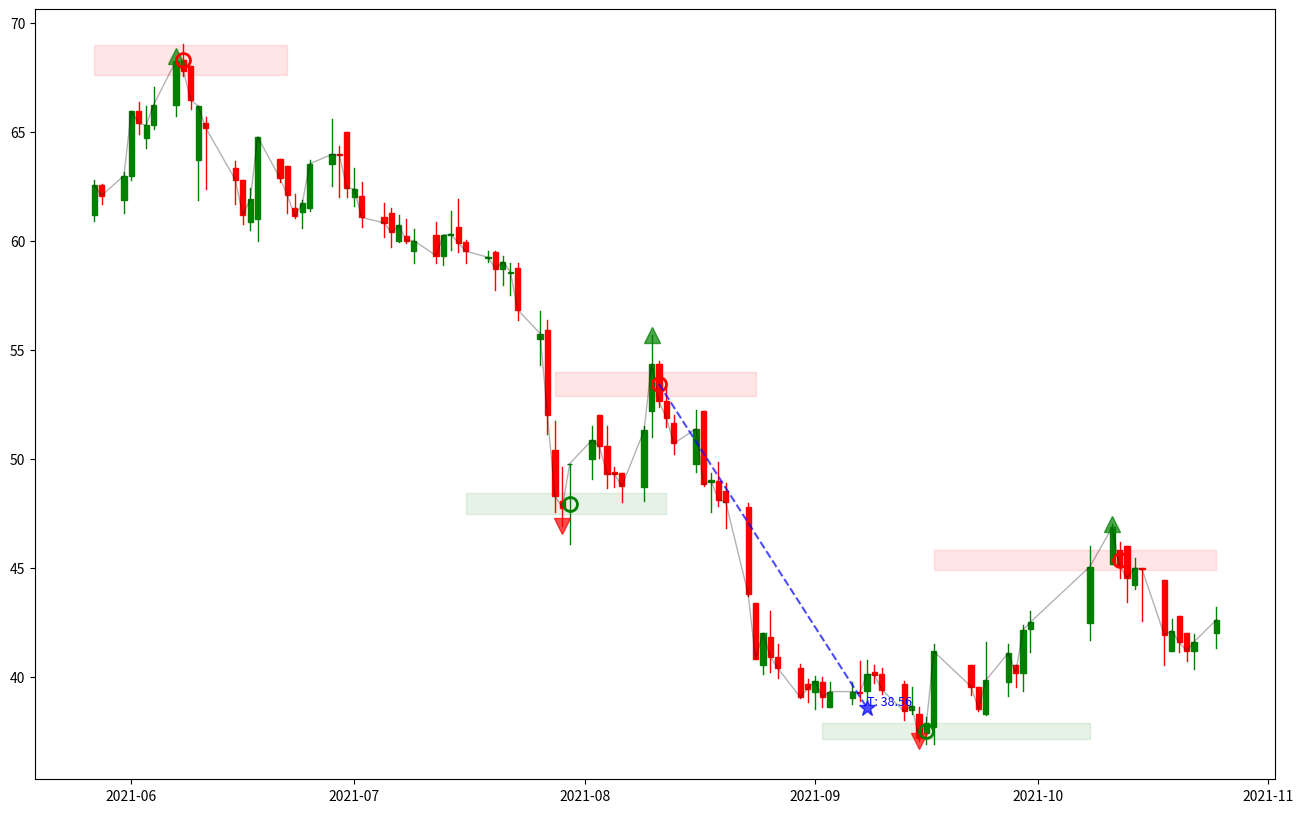

In [2]:
# 完整技术分析看盘程序 v1.0

import matplotlib.pyplot as plt
from matplotlib import gridspec
import argparse
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from matplotlib.patches import Rectangle
from scipy.stats import linregress
from scipy import stats, signal, cluster
from scipy.signal import find_peaks
from matplotlib import dates as mdates
from matplotlib.dates import DateFormatter
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def detect_pivot_points(df):
    """
    检测关键枢轴点：
    1. 上涨尖峰（连续上涨后的局部高点）
    2. 下跌尖峰（连续下跌后的局部低点）
    3. 中枢棒（尖峰后第一根反向K线）
    """
    close = df['close'].values
    high = df['high'].values
    low = df['low'].values
    open_ = df['open'].values
    
    # 1. 检测上涨尖峰（局部高点）
    up_peaks = find_peaks(close, prominence=np.std(close)*0.5)[0]
    
    # 2. 检测下跌尖峰（局部低点）
    down_peaks = find_peaks(-close, prominence=np.std(close)*0.5)[0]
    
    # 3. 检测中枢棒
    pivot_bars = []
    
    # 处理上涨尖峰
    for peak_idx in up_peaks:
        # 寻找尖峰后第一根阴棒（收盘<开盘）
        for i in range(peak_idx + 1, len(df)):
            if close[i] < open_[i]:
                pivot_bars.append({
                    'index': i,
                    'type': 'bearish_pivot',
                    'peak_index': peak_idx,
                    'price': (high[i] + low[i]) / 2,  # 中枢价格
                    'high': high[i],
                    'low': low[i]
                })
                break
    
    # 处理下跌尖峰
    for trough_idx in down_peaks:
        # 寻找尖峰后第一根阳棒（收盘>开盘）
        for i in range(trough_idx + 1, len(df)):
            if close[i] > open_[i]:
                pivot_bars.append({
                    'index': i,
                    'type': 'bullish_pivot',
                    'peak_index': trough_idx,
                    'price': (high[i] + low[i]) / 2,  # 中枢价格
                    'high': high[i],
                    'low': low[i]
                })
                break
    
    return up_peaks, down_peaks, pivot_bars

def identify_measurement_moves(pivot_bars):
    """
    识别测量运动：
    1. 计算中枢之间的距离
    2. 预测突破后的目标位
    """
    measurements = []
    pivot_prices = [bar['price'] for bar in pivot_bars]
    
    if len(pivot_prices) < 2:
        return measurements
    
    # 计算中枢间距离
    for i in range(1, len(pivot_bars)):
        prev_pivot = pivot_bars[i-1]
        curr_pivot = pivot_bars[i]
        
        distance = abs(curr_pivot['price'] - prev_pivot['price'])
        
        # 确定突破方向（基于中枢类型）
        if prev_pivot['type'] == 'bearish_pivot':
            direction = 'up' if curr_pivot['price'] > prev_pivot['price'] else 'down'
        else:
            direction = 'up' if curr_pivot['price'] > prev_pivot['price'] else 'down'
        
        # 预测目标位
        if direction == 'up':
            target = curr_pivot['price'] + distance
        else:
            target = curr_pivot['price'] - distance
        
        measurements.append({
            'start_index': curr_pivot['index'],
            'start_price': curr_pivot['price'],
            'distance': distance,
            'direction': direction,
            'target_price': target
        })
    
    return measurements

def visualize_pivot_system(df):
    """可视化枢轴点系统和中测量运动"""
    # 确保索引是DatetimeIndex类型
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            print("无法将索引转换为日期时间格式")
            return None
    
    # 检测枢轴点
    up_peaks, down_peaks, pivot_bars = detect_pivot_points(df)
    measurements = identify_measurement_moves(pivot_bars)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # 绘制K线图
    plot_candlestick(ax, df)
    ax.plot(df.index, df['close'], 'k-', alpha=0.3, linewidth=1)
    
    # 标记上涨尖峰
    for idx in up_peaks:
        ax.plot(df.index[idx], df['high'].iloc[idx], 'g^', markersize=12, alpha=0.7)
    
    # 标记下跌尖峰
    for idx in down_peaks:
        ax.plot(df.index[idx], df['low'].iloc[idx], 'rv', markersize=12, alpha=0.7)
    
    # 标记中枢棒并绘制中枢区域
    pivot_zones = []
    for bar in pivot_bars:
        idx = bar['index']
        date = df.index[idx]
        
        # 不同颜色标记不同类型的中枢
        if bar['type'] == 'bearish_pivot':
            color = 'red'
            ax.plot(date, bar['price'], 'ro', markersize=10, markeredgewidth=2, 
                    markerfacecolor='none', label='Bearish Pivot')
        else:
            color = 'green'
            ax.plot(date, bar['price'], 'go', markersize=10, markeredgewidth=2, 
                    markerfacecolor='none', label='Bullish Pivot')
        
        # 绘制中枢区域（最近20日高低点的50%范围）
        start_idx = max(0, idx - 10)
        end_idx = min(len(df), idx + 10)
        zone_high = df['high'].iloc[start_idx:end_idx].max()
        zone_low = df['low'].iloc[start_idx:end_idx].min()
        pivot_center = bar['price']
        
        # 绘制中枢区域
        ax.fill_between(df.index[start_idx:end_idx], 
                        pivot_center * 0.99, 
                        pivot_center * 1.01,
                        color=color, alpha=0.1)
        
        # 保存中枢信息
        pivot_zones.append({
            'start': start_idx,
            'end': end_idx,
            'center': pivot_center,
            'high': zone_high,
            'low': zone_low,
            'color': color
        })
    
    # 绘制测量运动
    for move in measurements:
        start_date = df.index[move['start_index']]
        start_price = move['start_price']
        target_price = move['target_price']
        
        # 确定结束位置（未来20个交易日）
        end_idx = min(len(df), move['start_index'] + 20)
        end_date = df.index[end_idx]
        
        # 绘制测量运动线和目标位
        ax.plot([start_date, end_date], [start_price, target_price], 
                'b--', linewidth=1.5, alpha=0.7)
        ax.plot(end_date, target_price, 'b*', markersize=12, alpha=0.7)
        
        # 标注测量信息
        ax.text(end_date, target_price, f'T: {target_price:.2f}',
                fontsize=9, ha='left', va='bottom', color='blue')
    
    # 绘制中枢间对称线
    if len(pivot_zones) >= 2:
        for i in range(1, len(pivot_zones)):
            prev = pivot_zones[i-1]
            curr = pivot_zones[i]
            
            # 计算中枢间距离
            distance = abs(curr['center'] - prev['center'])
            
            # 绘制对称线
            mid_date = df.index[(prev['end'] + curr['start']) // 2]
            ax.plot([df.index[prev['end']], [prev['center']]], 
                    [df.index[curr['start']], [curr['center']]], 
                    'm:', linewidth=1.2, alpha=0.6)
            
            # 标注距离
            ax.text(mid_date, (prev['center'] + curr['center'])/2, 
                    f'Δ: {distance:.2f}', fontsize=8, color='purple')
    
    # 设置图表格式
    ax.set_title('Pivot Point System & Measurement Moves', fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.6)
    date_format = DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    plt.xticks(rotation=45)
    
    # 创建图例
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor='g', markersize=10, label='Up Peak'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor='r', markersize=10, label='Down Peak'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='g', markersize=10, label='Bullish Pivot'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='r', markersize=10, label='Bearish Pivot'),
        Line2D([0], [0], linestyle='--', color='b', linewidth=1.5, label='Measurement Move'),
        Line2D([0], [0], marker='*', color='b', markersize=10, label='Target Price')
    ]
    ax.legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'up_peaks': up_peaks,
        'down_peaks': down_peaks,
        'pivot_bars': pivot_bars,
        'measurements': measurements
    }

def plot_candlestick(ax, df):
    """手动绘制K线图"""
    # 确保索引是日期格式
    dates = mdates.date2num(df.index.to_pydatetime())
    
    # 创建OHLC矩阵
    ohlc = []
    for i in range(len(df)):
        ohlc.append((dates[i], 
                     df.iloc[i]['open'], 
                     df.iloc[i]['high'], 
                     df.iloc[i]['low'], 
                     df.iloc[i]['close']))
    
    # 绘制K线
    width = 0.7 * (dates[1]-dates[0]) if len(dates) > 1 else 0.7
    
    for item in ohlc:
        date, open_price, high, low, close = item
        
        # 确定颜色
        color = 'green' if close >= open_price else 'red'
        
        # 绘制垂直线（最高到最低）
        ax.plot([date, date], [low, high], color=color, linewidth=1)
        
        # 绘制矩形（开盘到收盘）
        rect = plt.Rectangle((date - width/2, min(open_price, close)), 
                            width, 
                            abs(close - open_price), 
                            facecolor=color, 
                            edgecolor=color)
        ax.add_patch(rect)




    

# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='603755.SH',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20211025',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=100,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    # 使用示例（取消注释以运行）
    result = visualize_pivot_system(df)



    